<a href="https://colab.research.google.com/github/talmolab/sleap/blob/develop/docs/notebooks/Post_inference_tracking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Post-inference tracking

In tracking, we associate the poses (that were detected within individual frames) across time such that they belong to the same individual.

Since we typically do this separately, it is sometimes desirable to tweak the tracking parameters to optimize accuracy without having to re-run inference (e.g., `sleap-track` or `sleap-nn track`).

In this notebook, we will explore how to re-run the tracking given an existing predictions SLP file.

**Note:** Tracking does not run on the GPU, so this notebook can be run locally on your computer without the hassle of uploading your data if desired.

## 1. Setup

Run this cell first to install required libraries. If you get a dependency error in subsequent cells, just click **Runtime** → **Restart runtime** to reload the packages.


### Install

In [7]:
# This should take care of all the dependencies on colab:
!pip install -qqq "sleap-io"
!pip install -qqq "sleap-nn[torch-cpu]"

zsh:1: command not found: pip
zsh:1: command not found: pip


### Test

In [8]:
import sleap_io as sio

sio.__version__

'0.5.3'

In [9]:
import sleap_nn

sleap_nn.__version__

'0.0.1'

## 2. Setup data
Here we're downloading an existing `.slp` file with predictions and the corresponding `.mp4` video.

You should replace this with Google Drive mounting if running this on Google Colab, or simply skip it altogether and just set the paths below if running locally.

In [5]:
!wget -q -O fly_clip.mp4 "https://github.com/talmolab/sleap-tutorial-uo/blob/main/data/fly_clip.mp4?raw=true"
!wget -q -O predictions.slp "https://github.com/talmolab/sleap-tutorial-uo/blob/main/data/predictions.slp?raw=true"

In [6]:
PREDICTIONS_FILE = "predictions.slp"

## 3. Track

In [11]:
# Load predictions
labels = sio.load_slp(PREDICTIONS_FILE)

# Here I'm removing the tracks so we just have instances without any tracking applied.
for instance in labels.instances:
    instance.track = None
labels.tracks = []
labels

Labels(labeled_frames=1350, videos=1, skeletons=1, tracks=0, suggestions=0, sessions=0)

Here we create a tracker with the options we want to experiment with. You can [read more about tracking in the documentation](../../guides/tracking-and-proofreading/#tracking-methods) or the parameters in the [`sleap-track` CLI help](../../reference/command-line-interfaces/#inference-and-tracking) or [`sleap-nn track CLI`](https://nn.sleap.ai/latest/inference/#tracking).

In [12]:
# Create tracker
from sleap_nn.tracking.tracker import Tracker

tracker = Tracker.from_config(
    #general tracking options
    window_size=3,
    use_flow=True,

    # matching options
    min_new_track_points=1,
    min_match_points=1,
    features="keypoints",
    scoring_method="oks",
    track_matching_method="greedy",

    # optical flow options
    of_img_scale=0.5,
    of_window_size=21,
    of_max_levels=3,
)

Next we'll actually run the tracking on each frame. This might take a bit longer when using the `"flow"` method.

In [13]:
tracked_lfs = []
for lf in labels:
    lf.instances = tracker.track(lf.instances, frame_idx=lf.frame_idx, image=lf.image)
    tracked_lfs.append(lf)
tracked_labels = sio.Labels(tracked_lfs, videos=labels.videos, skeletons=labels.skeletons)
tracked_labels

Labels(labeled_frames=1350, videos=1, skeletons=1, tracks=2, suggestions=0, sessions=0)

## 4. Inspect and save

Let's see the results and save out the tracked predictions.

In [14]:
import seaborn as sns
from typing import Union, Tuple
import matplotlib.pyplot as plt
import numpy as np
import matplotlib

def imgfig(
    size: Union[float, Tuple] = 6, dpi: int = 72, scale: float = 1.0
) -> matplotlib.figure.Figure:
    """Create a tight figure for image plotting.

    Args:
        size: Scalar or 2-tuple specifying the (width, height) of the figure in inches.
            If scalar, will assume equal width and height.
        dpi: Dots per inch, controlling the resolution of the image.
        scale: Factor to scale the size of the figure by. This is a convenience for
            increasing the size of the plot at the same DPI.

    Returns:
        A matplotlib.figure.Figure to use for plotting.
    """
    if not isinstance(size, (tuple, list)):
        size = (size, size)
    fig = plt.figure(figsize=(scale * size[0], scale * size[1]), dpi=dpi)
    ax = fig.add_axes([0, 0, 1, 1], frameon=False)
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    plt.autoscale(tight=True)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(False)
    return fig

def plot_img(
    img: np.ndarray, dpi: int = 72, scale: float = 1.0
) -> matplotlib.figure.Figure:
    """Plot an image in a tight figure."""
    if hasattr(img, "numpy"):
        img = img.numpy()

    if img.shape[0] == 1:
        # Squeeze out batch singleton dimension.
        img = img.squeeze(axis=0)

    # Check if image is grayscale (single channel).
    grayscale = img.shape[-1] == 1
    if grayscale:
        # Squeeze out singleton channel.
        img = img.squeeze(axis=-1)

    # Normalize the range of pixel values.
    img_min = img.min()
    img_max = img.max()
    if img_min < 0.0 or img_max > 1.0:
        img = (img - img_min) / (img_max - img_min)

    fig = imgfig(
        size=(float(img.shape[1]) / dpi, float(img.shape[0]) / dpi),
        dpi=dpi,
        scale=scale,
    )

    ax = fig.gca()
    ax.imshow(
        img,
        cmap="gray" if grayscale else None,
        origin="upper",
        extent=[-0.5, img.shape[1] - 0.5, img.shape[0] - 0.5, -0.5],
    )
    return fig

def plot_instance(
    instance,
    skeleton=None,
    cmap=None,
    color_by_node=False,
    lw=2,
    ms=10,
    bbox=None,
    scale=1.0,
    **kwargs,
):
    """Plot a single instance with edge coloring."""
    if cmap is None:
        cmap = sns.color_palette("tab20")

    if skeleton is None and hasattr(instance, "skeleton"):
        skeleton = instance.skeleton

    if skeleton is None:
        color_by_node = True
    else:
        if len(skeleton.edges) == 0:
            color_by_node = True

    if hasattr(instance, "numpy"):
        inst_pts = instance.numpy()
    else:
        inst_pts = instance

    h_lines = []
    if color_by_node:
        for k, (x, y) in enumerate(inst_pts):
            if bbox is not None:
                x -= bbox[1]
                y -= bbox[0]

            x *= scale
            y *= scale

            h_lines_k = plt.plot(x, y, ".", ms=ms, c=cmap[k % len(cmap)], **kwargs)
            h_lines.append(h_lines_k)

    else:
        for k, (src_node, dst_node) in enumerate(skeleton.edges):
            pts = instance.numpy()
            src_pt = pts[skeleton.node_names.index(src_node.name)]
            dst_pt = pts[skeleton.node_names.index(dst_node.name)]

            x = np.array([src_pt[0], dst_pt[0]])
            y = np.array([src_pt[1], dst_pt[1]])

            if bbox is not None:
                x -= bbox[1]
                y -= bbox[0]

            x *= scale
            y *= scale

            h_lines_k = plt.plot(
                x, y, ".-", ms=ms, lw=lw, c=cmap[k % len(cmap)], **kwargs
            )

            h_lines.append(h_lines_k)

    return h_lines

def plot_instances(
    instances, skeleton=None, cmap=None, color_by_track=False, tracks=None, **kwargs
):
    """Plot a list of instances with identity coloring."""

    if cmap is None:
        cmap = sns.color_palette("tab10")

    if color_by_track and tracks is None:
        # Infer tracks for ordering if not provided.
        tracks = set()
        for instance in instances:
            tracks.add(instance.track)

        # Sort by spawned frame.
        tracks = sorted(list(tracks), key=lambda track: track.name)

    h_lines = []
    for i, instance in enumerate(instances):
        if color_by_track:
            if instance.track is None:
                raise ValueError(
                    "Instances must have a set track when coloring by track."
                )

            if instance.track not in tracks:
                raise ValueError("Instance has a track not found in specified tracks.")

            color = cmap[tracks.index(instance.track) % len(cmap)]

        else:
            # Color by identity (order in list).
            color = cmap[i % len(cmap)]

        h_lines_i = plot_instance(instance, skeleton=skeleton, cmap=[color], **kwargs)
        h_lines.append(h_lines_i)

    return h_lines

def plot(lf, scale=0.5):
    plot_img(lf.image, scale=scale)
    plot_instances(lf.instances)

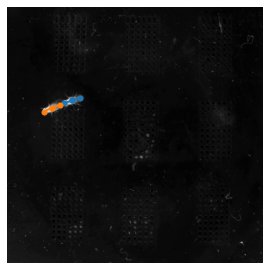

In [15]:
plot(tracked_labels[0], scale=0.25)

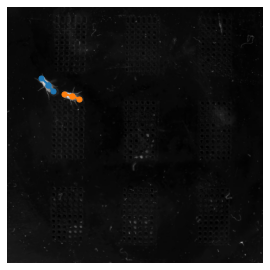

In [16]:
plot(tracked_labels[100], scale=0.25)

In [17]:
tracked_labels.save("retracked.slp")